In [1]:
import os
import sys
# sys.path.insert(1, '')
current_directory = os.getcwd()
print("Current Working Directory:", current_directory)

import vit_3d
import climate_dataset
import vivit
data_path = '/mnt/home/hwalters/data'
import numpy as np
import matplotlib.pyplot as plt

Current Working Directory: /Users/hayleywalters/Desktop/research 2025/ML_rain_prediction


In [2]:
import torch
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler

# Define patch sizes for padding calculation
IMAGE_PATCH_SIZE = (8, 8)  # Example patch size, adjust accordingly
FRAME_PATCH_SIZE = 8

def pad_video(video, patch_height, patch_width):
    """Pads the video spatial dimensions to be divisible by the patch size."""
    _, _, h, w = video.shape  # (Frames, Channels, Height, Width)
    
    pad_h = (patch_height - h % patch_height) % patch_height
    pad_w = (patch_width - w % patch_width) % patch_width

    if pad_h > 0 or pad_w > 0:
        padding = (0, pad_w, 0, pad_h)  # (Left, Right, Top, Bottom)
        video = F.pad(video, padding, mode='constant', value=0)  # Pad with zeros

    return video

def download_and_prepare_dataset(data_path, image_patch_size=IMAGE_PATCH_SIZE):
    """Loads and preprocesses the dataset, including padding."""
    with np.load(data_path, allow_pickle=True) as data:
        train_videos = np.nan_to_num(data["train_images"])
        valid_videos = np.nan_to_num(data["val_images"])
        test_videos = np.nan_to_num(data["test_images"])

        train_labels = data["train_labels"]
        valid_labels = data["val_labels"]
        test_labels = data["test_labels"]

    # Convert to PyTorch tensors
    train_videos = torch.tensor(train_videos, dtype=torch.float32)
    valid_videos = torch.tensor(valid_videos, dtype=torch.float32)
    test_videos = torch.tensor(test_videos, dtype=torch.float32)

    # Add channel dimension: (B, C, F, H, W)
    train_videos = train_videos[:, None, :, :, :]
    valid_videos = valid_videos[:, None, :, :, :]
    test_videos = test_videos[:, None, :, :, :]

    # Pad videos to make spatial dimensions divisible by patch size
    train_videos = torch.stack([pad_video(v, *image_patch_size) for v in train_videos])
    valid_videos = torch.stack([pad_video(v, *image_patch_size) for v in valid_videos])
    test_videos = torch.stack([pad_video(v, *image_patch_size) for v in test_videos])

    # Convert labels to tensors
    train_labels = torch.tensor(train_labels, dtype=torch.long)
    valid_labels = torch.tensor(valid_labels, dtype=torch.long)
    test_labels = torch.tensor(test_labels, dtype=torch.long)

    return (train_videos, train_labels), (valid_videos, valid_labels), (test_videos, test_labels)


def prepare_dataloader(videos, labels, loader_type="train", batch_size=32):
    """Creates a PyTorch DataLoader with preprocessed videos."""
    dataset = TensorDataset(videos, labels)

    if loader_type == "train":
        sampler = RandomSampler(dataset)
    else:
        sampler = None

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=(sampler is None),
        num_workers=0  # Adjust based on system
    )
    
    return dataloader


# Load and preprocess dataset
prepared_dataset = download_and_prepare_dataset("data/cluster_1_sst.npz")

train_videos, train_labels = prepared_dataset[0]
valid_videos, valid_labels = prepared_dataset[1]
test_videos, test_labels = prepared_dataset[2]

print(f'train_videos {train_videos.shape}, train_labels {train_labels.shape}')
print(f'valid_videos {valid_videos.shape}, valid_labels {valid_labels.shape}')
print(f'test_videos {test_videos.shape}, test_labels {test_labels.shape}')

# Create DataLoaders
trainloader = prepare_dataloader(train_videos, train_labels, "train", batch_size=32)
validloader = prepare_dataloader(valid_videos, valid_labels, "valid", batch_size=32)
testloader = prepare_dataloader(test_videos, test_labels, "test", batch_size=32)


train_videos torch.Size([585, 1, 24, 96, 184]), train_labels torch.Size([585])
valid_videos torch.Size([14, 1, 24, 96, 184]), valid_labels torch.Size([14])
test_videos torch.Size([133, 1, 24, 96, 184]), test_labels torch.Size([133])


In [ ]:
# print(vit_3d.run_experiment)  # Check if it's referencing your function
# model, history = vit_3d.run_experiment(trainloader, testloader, validloader)

In [ ]:
# import matplotlib.pyplot as plt
# epochs = range(1, len(history.training_loss) + 1)

# train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
# valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

# plt.plot(epochs, train_loss_norm, label="Training Loss (normalized)")
# plt.plot(epochs, valid_loss_norm, label="Validation Loss (normalized)")

# plt.xlabel("Epochs")
# plt.ylabel("Normalized Loss")
# plt.title("Training vs Validation Loss For Cluster 1 (Normalized)")
# plt.legend()
# plt.grid(True)
# plt.show()

NameError: name 'history' is not defined

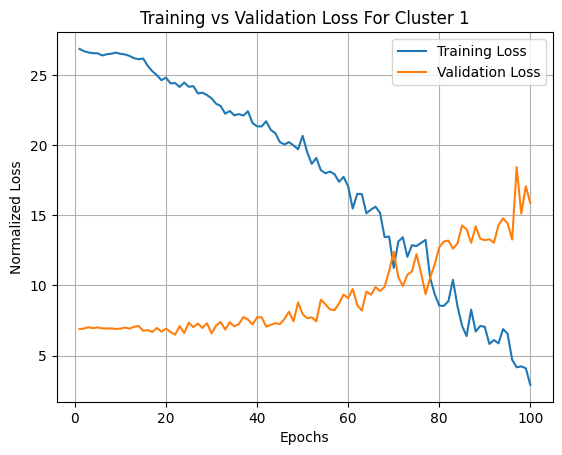

In [ ]:
# import matplotlib.pyplot as plt
# epochs = range(1, len(history.training_loss) + 1)

# # train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
# # valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

# plt.plot(epochs, history.training_loss, label="Training Loss")
# plt.plot(epochs, history.validation_loss, label="Validation Loss")

# plt.xlabel("Epochs")
# plt.ylabel("Normalized Loss")
# plt.title("Training vs Validation Loss For Cluster 1")
# plt.legend()
# plt.grid(True)
# plt.show()

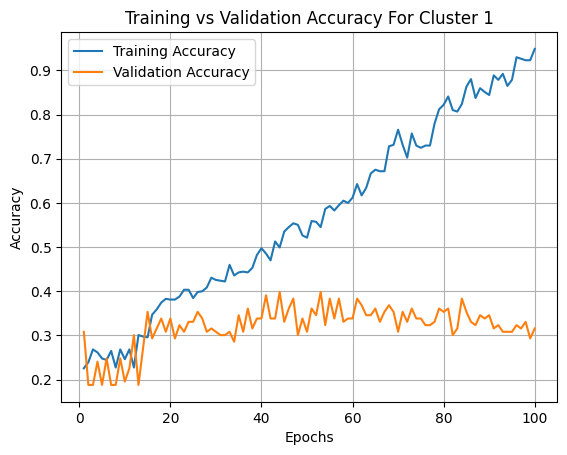

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy For Cluster 1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# print(vit_3d.run_experiment)  # Check if it's referencing your function
# model, history = vit_3d.run_experiment(trainloader, testloader, validloader)

<function run_experiment at 0x158ddf9d0>
image size (89, 180) patch size (8, 8) frames 24 frame_patch_size 8
Padding width to 184 to make it divisible by 8
Padding height to 96 to make it divisible by 8
Number of Patches 828 Patch dim 512
Epoch [1/10], Loss: 28.2940, Accuracy: 0.2547
Validation Accuracy: 0.1880, Validation Loss: 7.040199160575867
Epoch [2/10], Loss: 27.3453, Accuracy: 0.2462
Validation Accuracy: 0.2481, Validation Loss: 6.931374549865723
Epoch [3/10], Loss: 27.4195, Accuracy: 0.2359
Validation Accuracy: 0.3083, Validation Loss: 6.882157683372498
Epoch [4/10], Loss: 26.1567, Accuracy: 0.2923
Validation Accuracy: 0.1880, Validation Loss: 7.808990001678467
Epoch [5/10], Loss: 27.5975, Accuracy: 0.2239
Validation Accuracy: 0.1880, Validation Loss: 7.118225812911987
Epoch [6/10], Loss: 27.6705, Accuracy: 0.2393
Validation Accuracy: 0.1880, Validation Loss: 7.400360941886902
Epoch [7/10], Loss: 26.6502, Accuracy: 0.2855
Validation Accuracy: 0.2481, Validation Loss: 7.0005701

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler

# Define patch sizes for padding calculation
IMAGE_PATCH_SIZE = (8, 8)  # Example patch size, adjust accordingly
FRAME_PATCH_SIZE = 8

def pad_video(video, patch_height, patch_width):
    """Pads the video spatial dimensions to be divisible by the patch size."""
    _, _, h, w = video.shape  # (Frames, Channels, Height, Width)
    
    pad_h = (patch_height - h % patch_height) % patch_height
    pad_w = (patch_width - w % patch_width) % patch_width

    if pad_h > 0 or pad_w > 0:
        padding = (0, pad_w, 0, pad_h)  # (Left, Right, Top, Bottom)
        video = F.pad(video, padding, mode='constant', value=0)  # Pad with zeros

    return video

def download_and_prepare_dataset(data_path, image_patch_size=IMAGE_PATCH_SIZE):
    """Loads and preprocesses the dataset, including padding."""
    with np.load(data_path, allow_pickle=True) as data:
        train_videos = np.nan_to_num(data["train_images"])
        # valid_videos = np.nan_to_num(data["val_images"])
        test_videos = np.nan_to_num(data["test_images"])

        train_labels = data["train_labels"]
        # valid_labels = data["val_labels"]
        test_labels = data["test_labels"]

    # Convert to PyTorch tensors
    train_videos = torch.tensor(train_videos, dtype=torch.float32)
    # valid_videos = torch.tensor(valid_videos, dtype=torch.float32)
    test_videos = torch.tensor(test_videos, dtype=torch.float32)

    # Add channel dimension: (B, C, F, H, W)
    train_videos = train_videos[:, None, :, :, :]
    # valid_videos = valid_videos[:, None, :, :, :]
    test_videos = test_videos[:, None, :, :, :]

    # Pad videos to make spatial dimensions divisible by patch size
    train_videos = torch.stack([pad_video(v, *image_patch_size) for v in train_videos])
    # valid_videos = torch.stack([pad_video(v, *image_patch_size) for v in valid_videos])
    test_videos = torch.stack([pad_video(v, *image_patch_size) for v in test_videos])

    # Convert labels to tensors
    train_labels = torch.tensor(train_labels, dtype=torch.long)
    # valid_labels = torch.tensor(valid_labels, dtype=torch.long)
    test_labels = torch.tensor(test_labels, dtype=torch.long)

    # return (train_videos, train_labels), (valid_videos, valid_labels), (test_videos, test_labels)
    return (train_videos, train_labels), (test_videos, test_labels)


def prepare_dataloader(videos, labels, loader_type="train", batch_size=32):
    """Creates a PyTorch DataLoader with preprocessed videos."""
    dataset = TensorDataset(videos, labels)

    if loader_type == "train":
        sampler = RandomSampler(dataset)
    else:
        sampler = None

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=(sampler is None),
        num_workers=0  # Adjust based on system
    )
    
    return dataloader


# Load and preprocess dataset
# All 9 cluster data without validation data
# if we want to include testing and validation data, use 'data/cluster_sst_with_val.npz' and uncomment the lines relating to validation
prepared_dataset = download_and_prepare_dataset("data/cluster_sst.npz")

train_videos, train_labels = prepared_dataset[0]
# valid_videos, valid_labels = prepared_dataset[1]
test_videos, test_labels = prepared_dataset[1]

print(f'train_videos {train_videos.shape}, train_labels {train_labels.shape}')
# print(f'valid_videos {valid_videos.shape}, valid_labels {valid_labels.shape}')
print(f'test_videos {test_videos.shape}, test_labels {test_labels.shape}')

# Create DataLoaders
trainloader = prepare_dataloader(train_videos, train_labels, "train", batch_size=32)
# validloader = prepare_dataloader(valid_videos, valid_labels, "valid", batch_size=32)
testloader = prepare_dataloader(test_videos, test_labels, "test", batch_size=32)


train_videos torch.Size([585, 1, 24, 96, 184]), train_labels torch.Size([585, 9])
test_videos torch.Size([147, 1, 24, 96, 184]), test_labels torch.Size([147, 9])


### Fixed positional encoder, applied only to the time dimension

In [3]:
import vit_3d_9_classes
print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

<function run_experiment at 0x35618d430>
Number of Patches 828 Patch dim 512
Epoch [1/100], Loss: 1.4197 19, Accuracy: 0.2439
Validation Accuracy: 0.2275, Validation Loss: 1.3985
Epoch [2/100], Loss: 1.3920 19, Accuracy: 0.2367
Validation Accuracy: 0.2230, Validation Loss: 1.3978
Epoch [3/100], Loss: 1.3898 19, Accuracy: 0.2473
Validation Accuracy: 0.2071, Validation Loss: 1.3930
Epoch [4/100], Loss: 1.3912 19, Accuracy: 0.2443
Validation Accuracy: 0.2177, Validation Loss: 1.3934
Epoch [5/100], Loss: 1.3889 19, Accuracy: 0.2532
Validation Accuracy: 0.2177, Validation Loss: 1.3945
Epoch [6/100], Loss: 1.3889 19, Accuracy: 0.2460
Validation Accuracy: 0.2252, Validation Loss: 1.3920
Epoch [7/100], Loss: 1.3896 19, Accuracy: 0.2424
Validation Accuracy: 0.2222, Validation Loss: 1.3925
Epoch [8/100], Loss: 1.3894 19, Accuracy: 0.2465
Validation Accuracy: 0.2071, Validation Loss: 1.3966
Epoch [9/100], Loss: 1.3902 19, Accuracy: 0.2353
Validation Accuracy: 0.2260, Validation Loss: 1.3918
Epoch

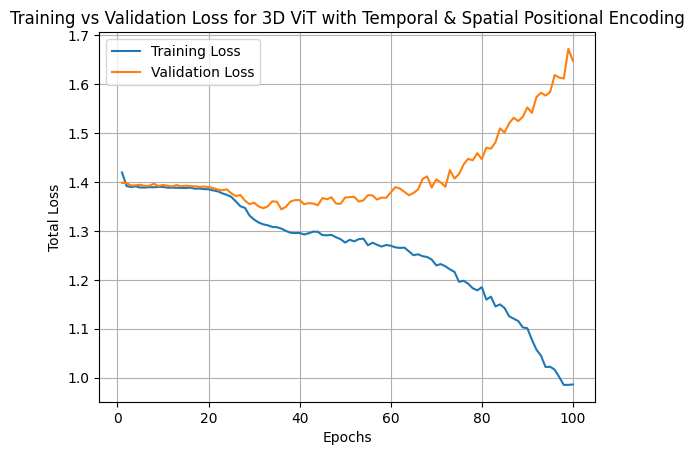

In [4]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)


plt.plot(epochs, history.training_loss, label="Training Loss")
plt.plot(epochs, history.validation_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Total Loss")
plt.title("Training vs Validation Loss for 3D ViT with Temporal & Spatial Positional Encoding")
plt.legend()
plt.grid(True)
plt.show()


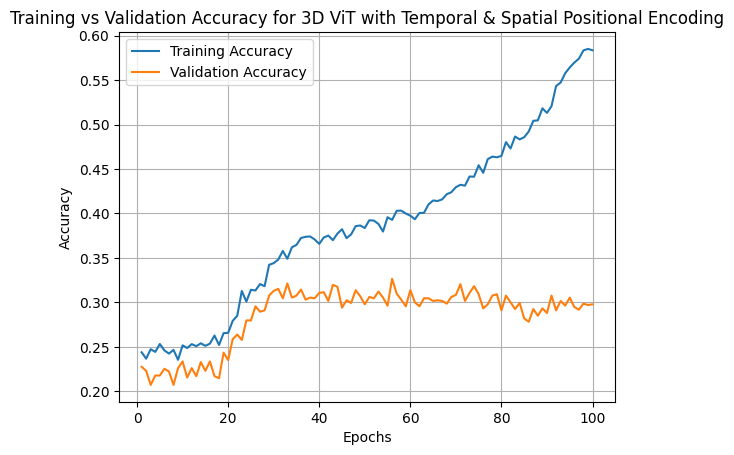

In [5]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy for 3D ViT with Temporal & Spatial Positional Encoding")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import vit_3d_9_classes
# Load the dataset with starting month information
prepared_dataset = vit_3d_9_classes.download_and_prepare_dataset("data/cluster_sst.npz")
(train_videos, train_labels, train_start_months), (test_videos, test_labels, test_start_months) = prepared_dataset

# Create dataloaders with starting month information
trainloader = vit_3d_9_classes.prepare_dataloader(train_videos, train_labels, train_start_months, "train", batch_size=32)
testloader = vit_3d_9_classes.prepare_dataloader(test_videos, test_labels, test_start_months, "test", batch_size=32)

# Run the experiment
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

Number of Patches 828 Patch dim 512


RuntimeError: output with shape [32, 12, 23, 128] doesn't match the broadcast shape [32, 32, 12, 23, 128]

In [8]:
max(history.validation_accuracy)

0.32653061224489793

In [14]:
np.save('data/history_temporal_positional_fixed.npy', history)

In [ ]:
max(history.validation_accuracy)

0.31495405179615704

In [ ]:
import vit_3d_9_classes
print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader, validloader)

<function run_experiment at 0x131c2b670>
Epoch [1/100], Loss: 26.6188, Accuracy: 0.2615
Validation Accuracy: 0.2556, Validation Loss: 6.949718594551086
Epoch [2/100], Loss: 26.3379, Accuracy: 0.2648
Validation Accuracy: 0.2648, Validation Loss: 6.897256016731262
Epoch [3/100], Loss: 26.3136, Accuracy: 0.2629
Validation Accuracy: 0.2573, Validation Loss: 6.900399088859558
Epoch [4/100], Loss: 26.3247, Accuracy: 0.2697
Validation Accuracy: 0.2406, Validation Loss: 6.922753214836121
Epoch [5/100], Loss: 26.2891, Accuracy: 0.2638
Validation Accuracy: 0.2707, Validation Loss: 6.884828209877014
Epoch [6/100], Loss: 26.3308, Accuracy: 0.2699
Validation Accuracy: 0.2682, Validation Loss: 6.907208561897278
Epoch [7/100], Loss: 26.3430, Accuracy: 0.2786
Validation Accuracy: 0.2673, Validation Loss: 6.917478322982788
Epoch [8/100], Loss: 26.2818, Accuracy: 0.2659
Validation Accuracy: 0.2531, Validation Loss: 6.931695580482483
Epoch [9/100], Loss: 26.2711, Accuracy: 0.2680
Validation Accuracy: 0.2

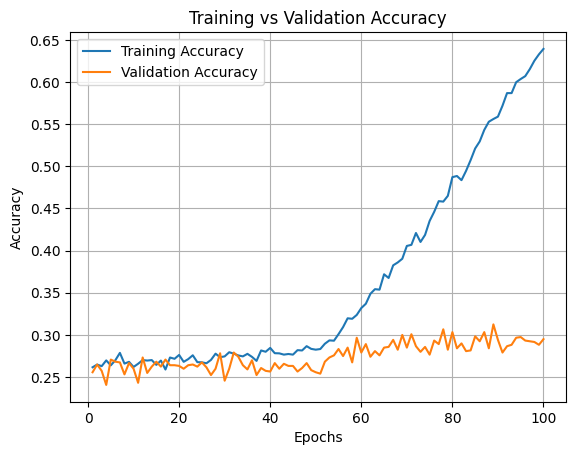

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

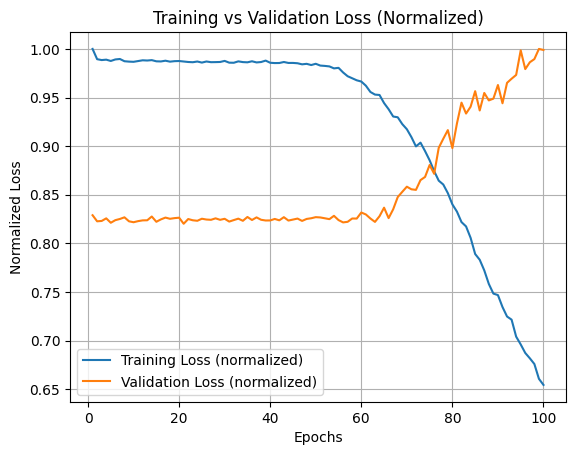

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)

train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

plt.plot(epochs, train_loss_norm, label="Training Loss (normalized)")
plt.plot(epochs, valid_loss_norm, label="Validation Loss (normalized)")

plt.xlabel("Epochs")
plt.ylabel("Normalized Loss")
plt.title("Training vs Validation Loss (Normalized)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import vit_3d_9_classes
print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader, validloader)

<function run_experiment at 0x14cb43040>
Number of Patches 828 Patch dim 512
Epoch [1/100], Loss: 26.7955, Accuracy: 0.2617
Validation Accuracy: 0.2515, Validation Loss: 6.944784164428711
Epoch [2/100], Loss: 26.3559, Accuracy: 0.2617
Validation Accuracy: 0.2573, Validation Loss: 6.92077112197876
Epoch [3/100], Loss: 26.3070, Accuracy: 0.2743
Validation Accuracy: 0.2573, Validation Loss: 6.942617774009705
Epoch [4/100], Loss: 26.3179, Accuracy: 0.2640
Validation Accuracy: 0.2523, Validation Loss: 6.92832612991333
Epoch [5/100], Loss: 26.3182, Accuracy: 0.2716
Validation Accuracy: 0.2481, Validation Loss: 6.896078586578369
Epoch [6/100], Loss: 26.3171, Accuracy: 0.2674
Validation Accuracy: 0.2732, Validation Loss: 6.918410301208496
Epoch [7/100], Loss: 26.2992, Accuracy: 0.2720
Validation Accuracy: 0.2690, Validation Loss: 6.909491181373596
Epoch [8/100], Loss: 26.2766, Accuracy: 0.2758
Validation Accuracy: 0.2673, Validation Loss: 6.918868184089661
Epoch [9/100], Loss: 26.2894, Accurac

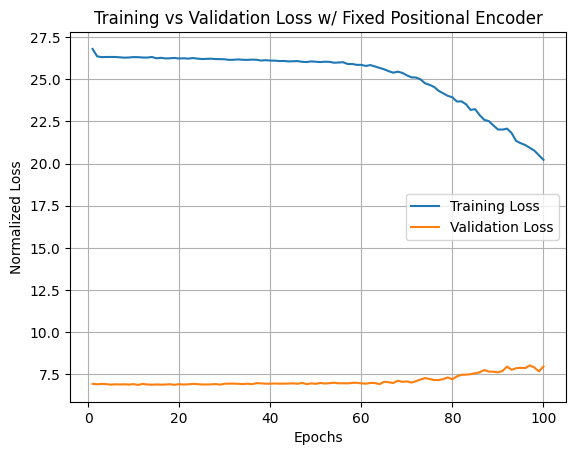

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)

train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

plt.plot(epochs, history.training_loss, label="Training Loss")
plt.plot(epochs, history.validation_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Normalized Loss")
plt.title("Training vs Validation Loss w/ Fixed Positional Encoder")
plt.legend()
plt.grid(True)
plt.show()


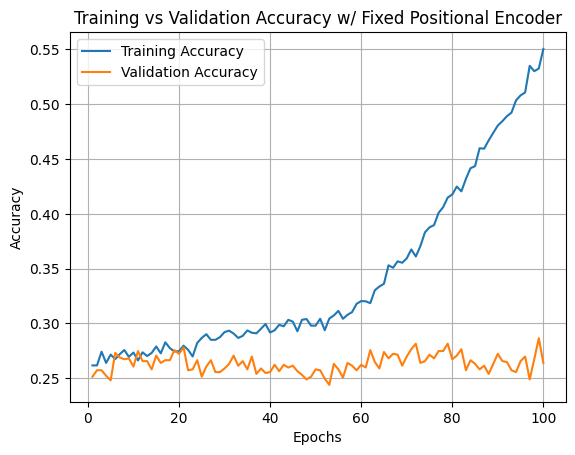

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy w/ Fixed Positional Encoder")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import vivit_pytorch
print(vivit_pytorch.run_experiment)  # Check if it's referencing your function
model, history = vivit_pytorch.run_experiment(trainloader, testloader, validloader)

<function run_experiment at 0x3742179d0>
Number of image patches 276
 Number of frame patches 3
 Patch dim 512
Epoch [1/100], Loss: 26.7554, Accuracy: 0.2634
Validation Accuracy: 0.2698, Validation Loss: 6.917448878288269
Epoch [2/100], Loss: 26.3314, Accuracy: 0.2686
Validation Accuracy: 0.2540, Validation Loss: 6.902013421058655
Epoch [3/100], Loss: 26.3013, Accuracy: 0.2657
Validation Accuracy: 0.2749, Validation Loss: 6.885661840438843
Epoch [4/100], Loss: 26.2997, Accuracy: 0.2682
Validation Accuracy: 0.2548, Validation Loss: 6.8972790241241455
Epoch [5/100], Loss: 26.3140, Accuracy: 0.2710
Validation Accuracy: 0.2556, Validation Loss: 6.937520503997803
Epoch [6/100], Loss: 26.3053, Accuracy: 0.2600
Validation Accuracy: 0.2632, Validation Loss: 6.939423084259033
Epoch [7/100], Loss: 26.3248, Accuracy: 0.2640
Validation Accuracy: 0.2648, Validation Loss: 6.922523856163025
Epoch [8/100], Loss: 26.3036, Accuracy: 0.2600
Validation Accuracy: 0.2665, Validation Loss: 6.913058042526245


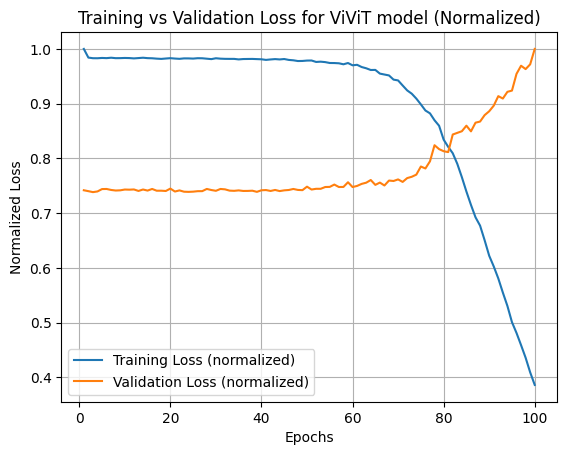

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)

train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

plt.plot(epochs, train_loss_norm, label="Training Loss (normalized)")
plt.plot(epochs, valid_loss_norm, label="Validation Loss (normalized)")

plt.xlabel("Epochs")
plt.ylabel("Normalized Loss")
plt.title("Training vs Validation Loss for ViViT model (Normalized)")
plt.legend()
plt.grid(True)
plt.show()

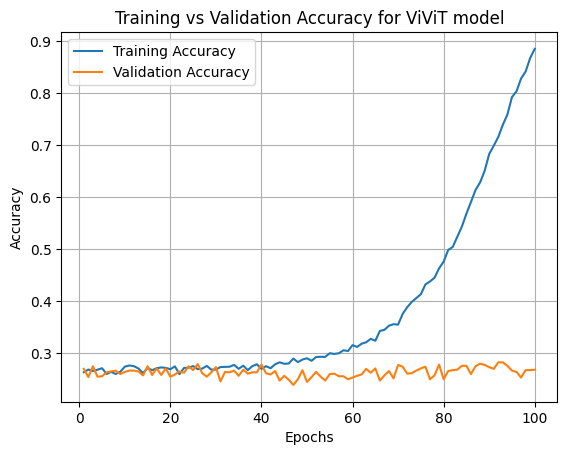

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy for ViViT model")
plt.legend()
plt.grid(True)
plt.show()

run w/ 3d positional embedding

In [ ]:
import vit_3d_9_classes
print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader, validloader)

<function run_experiment at 0x157a820d0>
Number of Patches 828 Patch dim 512
Epoch [1/100], Loss: 27.2183, Accuracy: 0.2726
Validation Accuracy: 0.2581, Validation Loss: 6.952890157699585
Epoch [2/100], Loss: 26.3807, Accuracy: 0.2665
Validation Accuracy: 0.2648, Validation Loss: 6.952989935874939
Epoch [3/100], Loss: 26.3380, Accuracy: 0.2615
Validation Accuracy: 0.2765, Validation Loss: 6.881179690361023
Epoch [4/100], Loss: 26.3064, Accuracy: 0.2665
Validation Accuracy: 0.2665, Validation Loss: 6.937520742416382
Epoch [5/100], Loss: 26.3184, Accuracy: 0.2710
Validation Accuracy: 0.2657, Validation Loss: 6.892169237136841
Epoch [6/100], Loss: 26.2790, Accuracy: 0.2657
Validation Accuracy: 0.2648, Validation Loss: 6.931076645851135
Epoch [7/100], Loss: 26.2915, Accuracy: 0.2718
Validation Accuracy: 0.2515, Validation Loss: 6.934197902679443
Epoch [8/100], Loss: 26.2745, Accuracy: 0.2672
Validation Accuracy: 0.2515, Validation Loss: 6.90946090221405
Epoch [9/100], Loss: 26.2751, Accura

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)

train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

plt.plot(epochs, train_loss_norm, label="Training Loss (normalized)")
plt.plot(epochs, valid_loss_norm, label="Validation Loss (normalized)")

plt.xlabel("Epochs")
plt.ylabel("Normalized Loss")
plt.title("Training vs Validation Loss for ViViT model (Normalized)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy for ViViT model")
plt.legend()
plt.grid(True)
plt.show()